# VTX Data Exploration

Initial exploration of IMU data from VTX files.

**Available Files**:
- `cornering_clockwise_1.vtx` - Original test: 4 right-hand corners around a block
- `up_hawk.vtx` - New recording
- `down_hawk_across_bridge.vtx` - New recording
- `bridge_down_through_marina.vtx` - New recording
- `marina_through_polk.vtx` - New recording  
- `17th_through_wiggle.vtx` - New recording
- `wiggle_to_bridge.vtx` - New recording
- `cleaned_up.vtx` - New test with updated firmware (VECTOR_LINEARACCEL)

**Goals**:
1. Load and inspect the data
2. Visualize raw sensor readings
3. Identify which axes correspond to forward/lateral/vertical using gravity
4. Check data quality
5. Compare characteristics across different ride recordings

**Important Notes**:
- Data includes gravity in the accelerometer readings
- One axis should show ~9.8 m/s² (or -9.8) when stationary - this is the vertical axis
- Road vibrations will add noise on top of the gravity component

In [1]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Add scripts to path
sys.path.insert(0, os.path.join(os.getcwd(), '../scripts'))

from load_vtx import load_vtx_file

# Configure plotting
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Try to enable interactive plotting with zoom/pan
# Falls back to inline if ipympl is not installed
try:
    %matplotlib widget
    print("✓ Interactive plotting enabled - use the toolbar to zoom/pan")
except:
    %matplotlib inline
    print("Using inline plots. Install ipympl for interactive zoom: pip install ipympl")
    print("Then restart kernel and re-run.")

✓ Interactive plotting enabled - use the toolbar to zoom/pan


## 1. Select and Load Data

Choose which file to analyze by uncommenting one of the options below.

In [2]:
# Select file to analyze - uncomment one:
# filename = 'cornering_clockwise_1.vtx'  # Original test data
# filename = 'up_hawk.vtx'
# filename = 'down_hawk_across_bridge.vtx'
# filename = 'bridge_down_through_marina.vtx'
# filename = 'marina_through_polk.vtx'
# filename = '17th_through_wiggle.vtx'
# filename = 'wiggle_to_bridge.vtx'
filename = 'cleaned_up.vtx'  # New firmware test (VECTOR_LINEARACCEL)

# Load the VTX file
data = load_vtx_file(f'../data/sample-recordings/{filename}')

header = data['header']
metadata = data['metadata']
df = data['samples']

print(f"=== FILE: {filename} ===")
print(f"Version: {header['version'][0]}.{header['version'][1]}")
print(f"Sample count: {header['sample_count']:,}")
print(f"Header sample rate: {header['sample_rate']:.1f} Hz")
print(f"Computed sample rate: {header['computed_sample_rate']:.1f} Hz")
print(f"Duration: {header['duration']:.2f} seconds ({header['duration']/60:.1f} minutes)")
print(f"\nColumns: {list(df.columns)}")
print(f"\n=== METADATA ===")
print(f"Device: {metadata.get('device', {}).get('name', 'Unknown')}")
print(f"Session: {metadata.get('session', {}).get('createdAt', 'Unknown')}")

=== FILE: cleaned_up.vtx ===
Version: 1.0
Sample count: 1,598
Header sample rate: 50.0 Hz
Computed sample rate: 49.4 Hz
Duration: 32.34 seconds (0.5 minutes)

Columns: ['timestamp', 'accel_x', 'accel_y', 'accel_z', 'gyro_x', 'gyro_y', 'gyro_z', 'mag_x', 'mag_y', 'mag_z', 'roll', 'pitch', 'yaw', 'time_sec']

=== METADATA ===
Device: Vertex-IMU
Session: 2025-11-07T06:03:17.658Z


In [3]:
# Show first few rows
df.head(10)

,timestamp,accel_x,accel_y,accel_z,gyro_x,gyro_y,gyro_z,mag_x,mag_y,mag_z,roll,pitch,yaw,time_sec
0,1762495397719,-0.02,-0.08,-0.11,-1.9375,1.6875,-2.5000,-6.0000,21.8750,-44.2500,3.842421,-1.448626,-23.660826,0.00
1,1762495397739,0.06,-0.19,-0.19,0.6250,-2.0000,3.0625,-6.0000,21.8750,-44.2500,3.824764,-1.465338,-23.632326,0.02
2,1762495397759,0.11,-0.12,-0.08,-0.0625,-0.0625,1.0625,-6.0000,21.5625,-43.8750,3.811412,-1.461488,-23.603193,0.04
3,1762495397779,-0.04,-0.13,-0.12,0.8750,0.6875,0.6250,-6.0000,21.5625,-43.8750,3.816956,-1.469570,-23.596684,0.06
4,1762495397799,0.08,-0.08,-0.06,-0.0625,1.5625,-1.5000,-6.0000,21.8750,-44.6875,3.825365,-1.463938,-23.589750,0.08
5,1762495397819,0.13,-0.21,-0.27,0.0625,-0.4375,-1.8750,-6.0000,21.8750,-44.6875,3.852263,-1.470875,-23.626013,0.10
6,1762495397839,0.08,0.11,-0.04,0.9375,-0.3750,-1.0625,-6.0000,21.8750,-44.6875,3.845090,-1.470421,-23.654741,0.12
7,1762495397859,-0.15,0.01,-0.01,-0.3125,0.7500,-0.0625,-6.6875,22.2500,-43.8750,3.839143,-1.462972,-23.681816,0.14
8,1762495397879,0.18,-0.08,-0.24,-1.3125,0.5000,-1.0000,-6.6875,22.2500,-43.8750,3.851598,-1.472845,-23.683741,0.16
9,1762495397899,0.12,-0.08,-0.13,-1.0000,0.1250,-0.1875,-6.3750,21.5625,-43.5000,3.850975,-1.508988,-23.698648,0.18


## 2. Basic Statistics

Calculate mean and standard deviation for each axis to identify patterns.

In [4]:
# Accelerometer statistics
print("=== ACCELEROMETER (m/s²) ===")
accel_cols = ['accel_x', 'accel_y', 'accel_z']
accel_stats = df[accel_cols].describe()
print(accel_stats)

print("\n=== GYROSCOPE (rad/s) ===")
gyro_cols = ['gyro_x', 'gyro_y', 'gyro_z']
gyro_stats = df[gyro_cols].describe()
print(gyro_stats)

if 'mag_x' in df.columns:
    print("\n=== MAGNETOMETER (µT) ===")
    mag_cols = ['mag_x', 'mag_y', 'mag_z']
    mag_stats = df[mag_cols].describe()
    print(mag_stats)

=== ACCELEROMETER (m/s²) ===
           accel_x      accel_y      accel_z
count  1598.000000  1598.000000  1598.000000
mean      0.064737    -0.021621    -0.112879
std       1.024007     1.221292     0.917230
min      -7.080000    -7.200000    -4.820000
25%      -0.180000    -0.327500    -0.340000
50%       0.090000    -0.010000    -0.100000
75%       0.370000     0.280000     0.120000
max       5.380000     7.230000     6.400000

=== GYROSCOPE (rad/s) ===
            gyro_x       gyro_y       gyro_z
count  1598.000000  1598.000000  1598.000000
mean      0.612758    -0.301549     0.497849
std      28.992935    27.206031    33.638175
min    -137.562500  -130.937500  -126.562500
25%      -5.921875    -8.609375    -6.125000
50%       0.781250    -0.250000     0.156250
75%       6.609375     5.609375     8.484375
max     178.000000   181.625000   181.875000

=== MAGNETOMETER (µT) ===
             mag_x        mag_y        mag_z
count  1598.000000  1598.000000  1598.000000
mean     -6.03109

## 3. Identify Axes

Use statistical analysis to identify which axis corresponds to:
- **Vertical (Z)**: Should show mean close to ±9.8 m/s² (gravity)
- **Forward (X)**: Usually along the bike's forward direction
- **Lateral (Y)**: Side-to-side, perpendicular to forward motion

We'll look at the mean values to find which axis has gravity.

In [5]:
# Calculate metrics for axis identification
# Look for gravity signature to identify vertical axis

axes_analysis = []
for axis in ['x', 'y', 'z']:
    col = f'accel_{axis}'
    mean_val = df[col].mean()
    variance = df[col].var()
    std_val = df[col].std()
    
    # Calculate high-frequency noise (difference between consecutive samples)
    noise = df[col].diff().abs().mean()
    
    axes_analysis.append({
        'axis': axis,
        'mean': mean_val,
        'abs_mean': abs(mean_val),
        'variance': variance,
        'std': std_val,
        'noise': noise
    })

axes_df = pd.DataFrame(axes_analysis)
print("=== AXIS ANALYSIS ===")
print(axes_df)

# Identify vertical axis by finding which mean is closest to ±9.8 m/s² (gravity)
gravity = 9.8
axes_df['gravity_diff'] = abs(axes_df['abs_mean'] - gravity)
vertical_axis = axes_df.loc[axes_df['gravity_diff'].idxmin(), 'axis']
vertical_mean = axes_df.loc[axes_df['gravity_diff'].idxmin(), 'mean']

remaining = axes_df[axes_df['axis'] != vertical_axis]

# Forward: Higher variance of the remaining (acceleration/braking events)
forward_axis = remaining.loc[remaining['variance'].idxmax(), 'axis']

# Lateral: Remaining axis (turns/corners)
lateral_axis = remaining[remaining['axis'] != forward_axis].iloc[0]['axis']

print(f"\n=== IDENTIFIED AXES ===")
print(f"Vertical (Z): {vertical_axis.upper()} (mean: {vertical_mean:.3f} m/s², expected: ±9.8 m/s²)")
print(f"Forward (X): {forward_axis.upper()} (variance: {axes_df[axes_df['axis']==forward_axis]['variance'].iloc[0]:.3f})")
print(f"Lateral (Y): {lateral_axis.upper()} (variance: {axes_df[axes_df['axis']==lateral_axis]['variance'].iloc[0]:.3f})")

# Verify gravity detection
if axes_df.loc[axes_df['axis']==vertical_axis, 'gravity_diff'].iloc[0] < 2.0:
    print(f"\n✓ Gravity detected on {vertical_axis.upper()} axis (difference: {axes_df.loc[axes_df['axis']==vertical_axis, 'gravity_diff'].iloc[0]:.3f} m/s²)")
else:
    print(f"\n⚠ Warning: No clear gravity signature found. Device might be mounted at an angle or data may be pre-processed.")

=== AXIS ANALYSIS ===
  axis      mean  abs_mean  variance       std     noise
0    x  0.064737  0.064737  1.048591  1.024007  0.614164
1    y -0.021621  0.021621  1.491553  1.221292  0.685147
2    z -0.112879  0.112879  0.841311  0.917230  0.467439

=== IDENTIFIED AXES ===
Vertical (Z): Z (mean: -0.113 m/s², expected: ±9.8 m/s²)
Forward (X): Y (variance: 1.492)
Lateral (Y): X (variance: 1.049)

⚠ Warning: No clear gravity signature found. Device might be mounted at an angle or data may be pre-processed.


## 4. Visualize Raw Data

Plot all axes over time to see patterns. The vertical axis should show gravity (~9.8 m/s²) plus dynamic acceleration.

**Interactive controls**: Use the toolbar to zoom/pan. Or adjust the time window below to focus on a specific section.

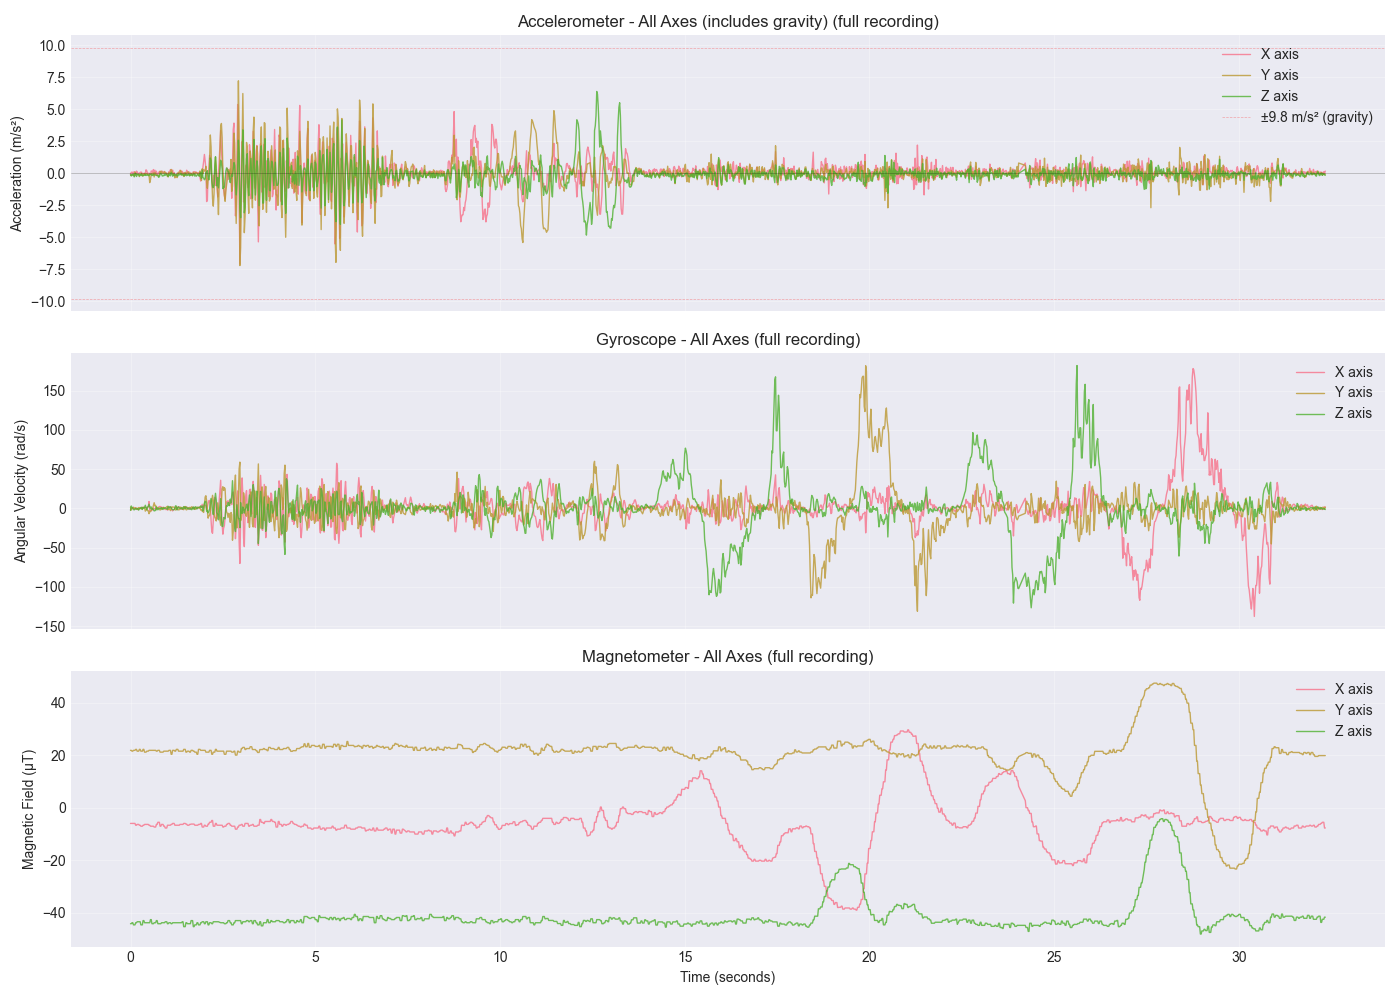

In [6]:
# Optional: Set time window to focus on (in seconds)
# Set to None to see full recording
time_start = None  # Start time in seconds (or None for beginning)
time_end = None    # End time in seconds (or None for end)

# Example: To see first 60 seconds, uncomment:
# time_start = 0
# time_end = 60

# Filter data if time window specified
if time_start is not None or time_end is not None:
    mask = pd.Series([True] * len(df))
    if time_start is not None:
        mask &= df['time_sec'] >= time_start
    if time_end is not None:
        mask &= df['time_sec'] <= time_end
    df_plot = df[mask].copy()
    window_label = f" ({time_start or 0:.0f}s - {time_end or header['duration']:.0f}s)"
else:
    df_plot = df
    window_label = " (full recording)"

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Accelerometer (includes gravity)
for axis in ['x', 'y', 'z']:
    axes[0].plot(df_plot['time_sec'], df_plot[f'accel_{axis}'], label=f'{axis.upper()} axis', alpha=0.8, linewidth=1)
axes[0].axhline(y=0, color='k', linestyle='-', alpha=0.3, linewidth=0.5)
axes[0].axhline(y=9.8, color='r', linestyle='--', alpha=0.3, linewidth=0.5, label='±9.8 m/s² (gravity)')
axes[0].axhline(y=-9.8, color='r', linestyle='--', alpha=0.3, linewidth=0.5)
axes[0].set_ylabel('Acceleration (m/s²)')
axes[0].set_title(f'Accelerometer - All Axes (includes gravity){window_label}')
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3)

# Gyroscope
for axis in ['x', 'y', 'z']:
    axes[1].plot(df_plot['time_sec'], df_plot[f'gyro_{axis}'], label=f'{axis.upper()} axis', alpha=0.8, linewidth=1)
axes[1].set_ylabel('Angular Velocity (rad/s)')
axes[1].set_title(f'Gyroscope - All Axes{window_label}')
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

# Magnetometer (if available)
if 'mag_x' in df.columns:
    for axis in ['x', 'y', 'z']:
        axes[2].plot(df_plot['time_sec'], df_plot[f'mag_{axis}'], label=f'{axis.upper()} axis', alpha=0.8, linewidth=1)
    axes[2].set_ylabel('Magnetic Field (µT)')
    axes[2].set_title(f'Magnetometer - All Axes{window_label}')
    axes[2].legend(loc='upper right')
    axes[2].grid(True, alpha=0.3)
else:
    axes[2].text(0.5, 0.5, 'No magnetometer data', ha='center', va='center')
    axes[2].set_title('Magnetometer - Not Available')

axes[2].set_xlabel('Time (seconds)')
plt.tight_layout()
plt.show()

## 5. Detect Acceleration and Braking Events

Since we don't have Euler angles yet, let's analyze what we CAN detect from raw data:
forward acceleration and braking! The X-axis (forward) should show much clearer signals
than the Y-axis (lateral) for these events.

**Strategy:**
1. Apply optimal Butterworth filtering to remove road vibration noise
2. Detect acceleration events (positive X-axis spikes)
3. Detect braking events (negative X-axis spikes)

=== FORWARD ACCELERATION ANALYSIS ===
Using forward axis: X
Sample rate: 49.5 Hz

Raw forward acceleration:
  Mean: -0.827 m/s²
  Std: 5.629 m/s²
  Range: [-39.250, 39.190] m/s²

Filtered (0.5 Hz cutoff):
  Mean: -0.827 m/s²
  Std: 0.857 m/s²
  Range: [-4.721, 2.031] m/s²
  Noise reduction: 84.8%

Filtered (1.0 Hz cutoff):
  Mean: -0.827 m/s²
  Std: 1.055 m/s²
  Range: [-5.839, 3.793] m/s²
  Noise reduction: 81.3%

Filtered (2.0 Hz cutoff):
  Mean: -0.827 m/s²
  Std: 1.372 m/s²
  Range: [-9.561, 7.759] m/s²
  Noise reduction: 75.6%

Filtered (3.0 Hz cutoff):
  Mean: -0.827 m/s²
  Std: 1.673 m/s²
  Range: [-13.378, 10.980] m/s²
  Noise reduction: 70.3%


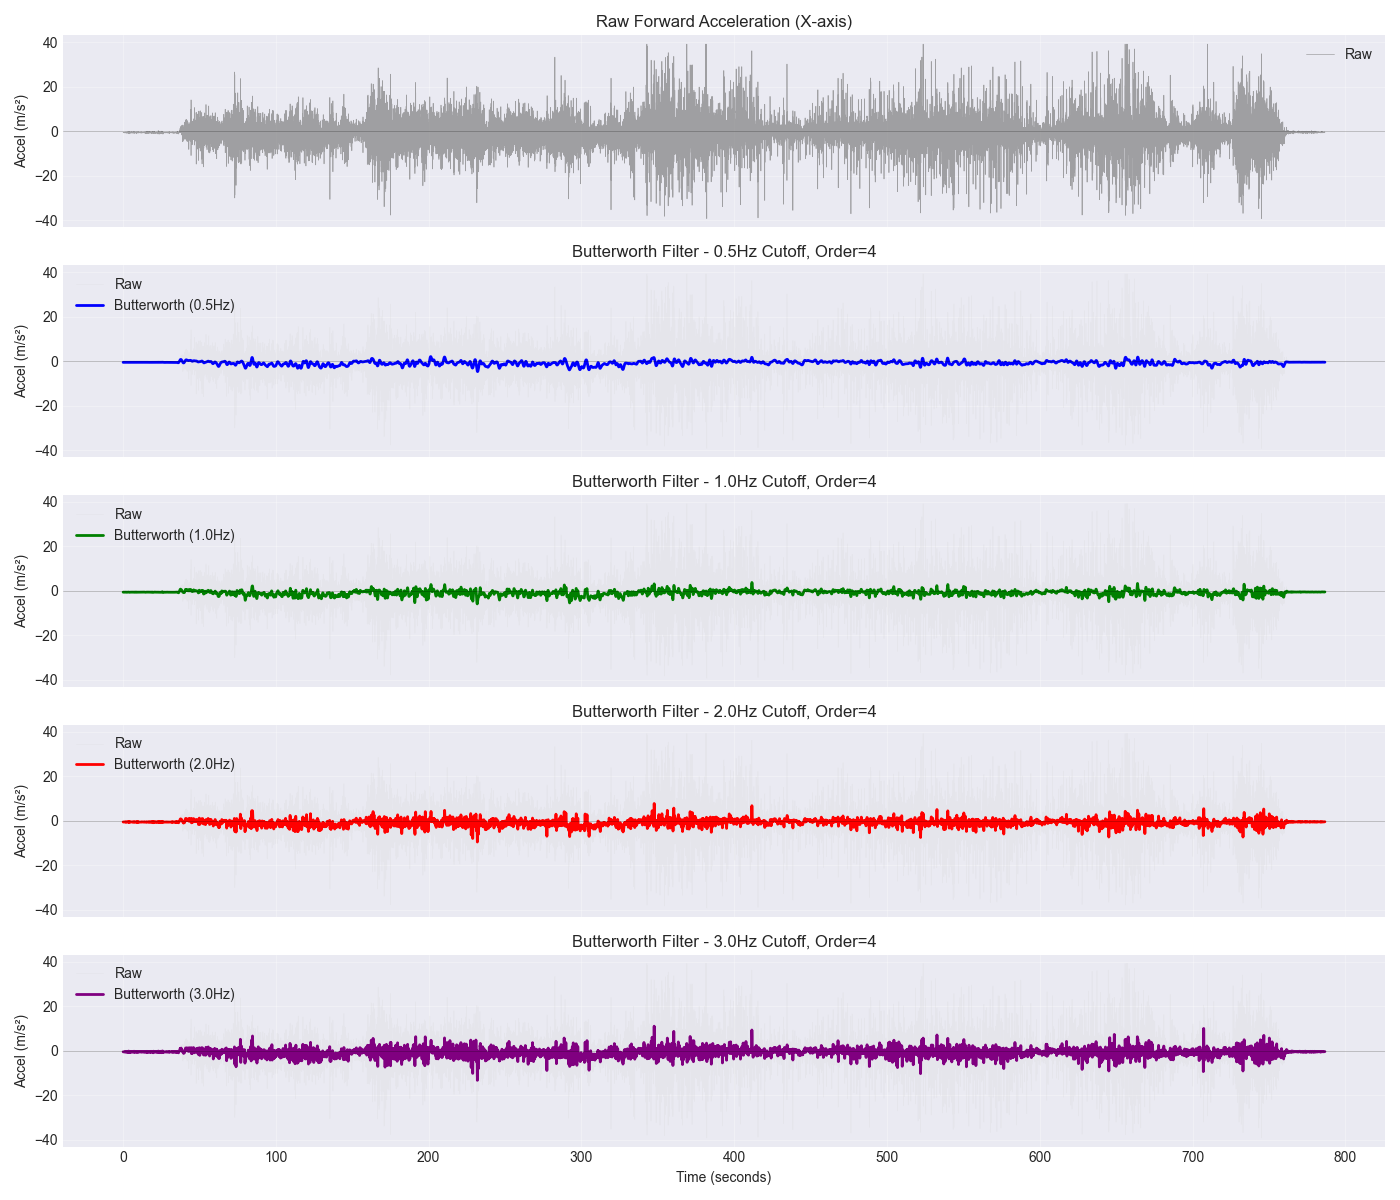


✓ Try different cutoff frequencies to balance noise reduction vs signal preservation
  Lower cutoff = smoother but may miss quick acceleration/braking
  Higher cutoff = preserves quick events but keeps more noise


In [8]:
# Implement smoothing functions
from scipy import signal

def butterworth_lowpass(data, cutoff=5.0, sample_rate=None, order=4):
    """
    Apply Butterworth low-pass filter
    
    Args:
        data: Input signal
        cutoff: Cutoff frequency in Hz (remove noise above this)
        sample_rate: Sample rate in Hz
        order: Filter order (higher = sharper cutoff)
    """
    if sample_rate is None:
        raise ValueError("Sample rate must be provided")
    
    nyquist = sample_rate / 2
    normal_cutoff = cutoff / nyquist
    
    if normal_cutoff >= 1.0:
        raise ValueError(f"Cutoff frequency ({cutoff} Hz) must be less than Nyquist frequency ({nyquist} Hz)")
    
    b, a = signal.butter(order, normal_cutoff, btype='low', analog=False)
    return signal.filtfilt(b, a, data)

# Get forward acceleration (X-axis)
forward_col = f'accel_{forward_axis}'
forward_data = df[forward_col].values
sample_rate = header['computed_sample_rate']

print(f"=== FORWARD ACCELERATION ANALYSIS ===")
print(f"Using forward axis: {forward_axis.upper()}")
print(f"Sample rate: {sample_rate:.1f} Hz")
print(f"\nRaw forward acceleration:")
print(f"  Mean: {forward_data.mean():.3f} m/s²")
print(f"  Std: {forward_data.std():.3f} m/s²")
print(f"  Range: [{forward_data.min():.3f}, {forward_data.max():.3f}] m/s²")

# Test different cutoff frequencies to find optimal smoothing
cutoff_frequencies = [0.5, 1.0, 2.0, 3.0]
filtered_signals = {}

for cutoff in cutoff_frequencies:
    filtered = butterworth_lowpass(forward_data, cutoff=cutoff, sample_rate=sample_rate, order=4)
    filtered_signals[cutoff] = filtered
    print(f"\nFiltered ({cutoff} Hz cutoff):")
    print(f"  Mean: {filtered.mean():.3f} m/s²")
    print(f"  Std: {filtered.std():.3f} m/s²")
    print(f"  Range: [{filtered.min():.3f}, {filtered.max():.3f}] m/s²")
    print(f"  Noise reduction: {(1 - filtered.std()/forward_data.std())*100:.1f}%")

# Plot comparison of different cutoff frequencies
fig, axes = plt.subplots(len(cutoff_frequencies) + 1, 1, figsize=(14, 12), sharex=True)

# Raw data
axes[0].plot(df['time_sec'], forward_data, label='Raw', linewidth=0.5, alpha=0.7, color='gray')
axes[0].axhline(y=0, color='k', linestyle='-', alpha=0.3, linewidth=0.5)
axes[0].set_ylabel('Accel (m/s²)')
axes[0].set_title('Raw Forward Acceleration (X-axis)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Filtered versions
colors = ['blue', 'green', 'red', 'purple']
for i, cutoff in enumerate(cutoff_frequencies):
    axes[i+1].plot(df['time_sec'], forward_data, label='Raw', linewidth=0.5, alpha=0.2, color='lightgray')
    axes[i+1].plot(df['time_sec'], filtered_signals[cutoff], 
                   label=f'Butterworth ({cutoff}Hz)', linewidth=2, color=colors[i])
    axes[i+1].axhline(y=0, color='k', linestyle='-', alpha=0.3, linewidth=0.5)
    axes[i+1].set_ylabel('Accel (m/s²)')
    axes[i+1].set_title(f'Butterworth Filter - {cutoff}Hz Cutoff, Order=4')
    axes[i+1].legend()
    axes[i+1].grid(True, alpha=0.3)

axes[-1].set_xlabel('Time (seconds)')
plt.tight_layout()
plt.show()

print("\n✓ Try different cutoff frequencies to balance noise reduction vs signal preservation")
print("  Lower cutoff = smoother but may miss quick acceleration/braking")
print("  Higher cutoff = preserves quick events but keeps more noise")

## 6. Detect Acceleration and Braking Events

Now let's use peak detection to find significant acceleration and braking events.

In [9]:
from scipy.signal import find_peaks

# Use 1.5Hz cutoff - good balance between noise reduction and event detection
optimal_cutoff = 1.5
forward_filtered = butterworth_lowpass(forward_data, cutoff=optimal_cutoff, sample_rate=sample_rate, order=4)

print(f"=== EVENT DETECTION ===")
print(f"Using {optimal_cutoff}Hz Butterworth filter")
print(f"Sample rate: {sample_rate:.1f} Hz")

# Detect acceleration events (positive peaks)
accel_threshold = 2.0  # m/s² above mean
accel_min_distance = int(sample_rate * 2)  # Minimum 2 seconds between events
accel_min_prominence = 1.5  # Must change by at least 1.5 m/s²

accel_peaks, accel_props = find_peaks(
    forward_filtered,
    height=forward_filtered.mean() + accel_threshold,
    distance=accel_min_distance,
    prominence=accel_min_prominence,
    width=int(sample_rate * 2.0)  # Must be sustained for at least 2.0 seconds
)

# Detect braking events (negative peaks)
braking_threshold = -2.0  # m/s² below mean
braking_peaks, braking_props = find_peaks(
    -forward_filtered,  # Invert signal to find negative peaks
    height=-(forward_filtered.mean() + braking_threshold),
    distance=accel_min_distance,
    prominence=accel_min_prominence,
    width=int(sample_rate * 2.0)  # Must be sustained for at least 2.0 seconds
)

print(f"\n=== DETECTION RESULTS ===")
print(f"Acceleration events: {len(accel_peaks)}")
print(f"Braking events: {len(braking_peaks)}")
print(f"\nThresholds:")
print(f"  Acceleration: >{accel_threshold:.1f} m/s² above baseline")
print(f"  Braking: <{braking_threshold:.1f} m/s² below baseline")
print(f"  Min prominence: {accel_min_prominence:.1f} m/s²")
print(f"  Min distance: {accel_min_distance/sample_rate:.1f}s between events")
print(f"  Min duration: 2.0s sustained")

# Store filtered data for plotting
df['forward_filtered'] = forward_filtered

=== EVENT DETECTION ===
Using 1.5Hz Butterworth filter
Sample rate: 49.5 Hz

=== DETECTION RESULTS ===
Acceleration events: 11
Braking events: 13

Thresholds:
  Acceleration: >2.0 m/s² above baseline
  Braking: <-2.0 m/s² below baseline
  Min prominence: 1.5 m/s²
  Min distance: 2.0s between events
  Min duration: 2.0s sustained


## 7. Visualize Acceleration and Braking Events

Plot the filtered forward acceleration with detected events marked.

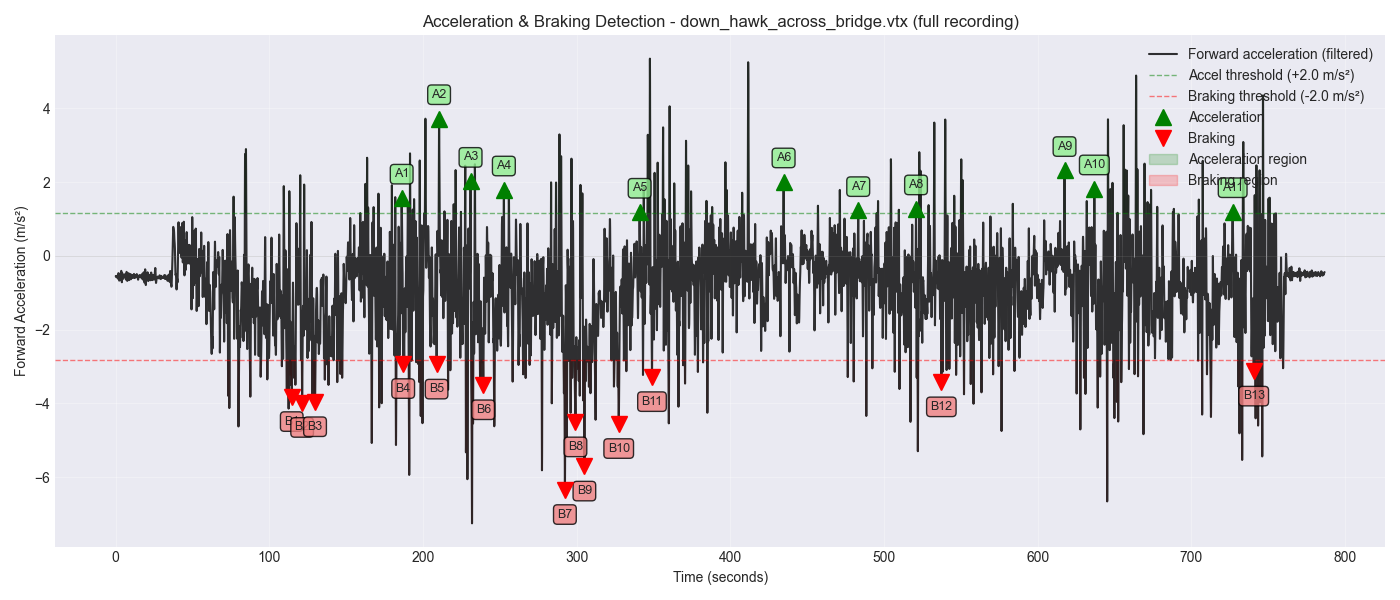


=== ACCELERATION EVENTS ===
A1: t= 186.08s, accel=  1.57 m/s²
A2: t= 210.42s, accel=  3.73 m/s²
A3: t= 230.90s, accel=  2.03 m/s²
A4: t= 252.58s, accel=  1.79 m/s²
A5: t= 340.92s, accel=  1.19 m/s²
A6: t= 434.62s, accel=  2.01 m/s²
A7: t= 483.18s, accel=  1.23 m/s²
A8: t= 520.80s, accel=  1.28 m/s²
A9: t= 617.44s, accel=  2.32 m/s²
A10: t= 636.84s, accel=  1.82 m/s²
A11: t= 726.86s, accel=  1.20 m/s²

=== BRAKING EVENTS ===
B1: t= 114.54s, accel= -3.82 m/s² (deceleration)
B2: t= 121.30s, accel= -3.98 m/s² (deceleration)
B3: t= 129.70s, accel= -3.96 m/s² (deceleration)
B4: t= 187.06s, accel= -2.93 m/s² (deceleration)
B5: t= 208.80s, accel= -2.94 m/s² (deceleration)
B6: t= 239.18s, accel= -3.50 m/s² (deceleration)
B7: t= 292.30s, accel= -6.34 m/s² (deceleration)
B8: t= 299.18s, accel= -4.51 m/s² (deceleration)
B9: t= 304.98s, accel= -5.71 m/s² (deceleration)
B10: t= 327.32s, accel= -4.55 m/s² (deceleration)
B11: t= 348.98s, accel= -3.28 m/s² (deceleration)
B12: t= 537.28s, accel= -3.42 

In [10]:
# Optional: Set time window to focus on
time_start_events = None
time_end_events = None

# Example: Focus on a specific section
# time_start_events = 100
# time_end_events = 200

# Filter data if time window specified
if time_start_events is not None or time_end_events is not None:
    mask = pd.Series([True] * len(df))
    if time_start_events is not None:
        mask &= df['time_sec'] >= time_start_events
    if time_end_events is not None:
        mask &= df['time_sec'] <= time_end_events
    df_events_plot = df[mask].copy()
    events_window_label = f" ({time_start_events or 0:.0f}s - {time_end_events or header['duration']:.0f}s)"
else:
    df_events_plot = df
    events_window_label = " (full recording)"

fig, ax = plt.subplots(1, 1, figsize=(14, 6))

# Plot filtered forward acceleration
ax.plot(df_events_plot['time_sec'], df_events_plot['forward_filtered'], 
        linewidth=1.5, alpha=0.8, color='black', label='Forward acceleration (filtered)')
ax.axhline(y=0, color='gray', linestyle='-', alpha=0.3, linewidth=0.5)

# Threshold lines
ax.axhline(y=forward_filtered.mean() + accel_threshold, color='green', linestyle='--', 
           alpha=0.5, linewidth=1, label=f'Accel threshold (+{accel_threshold} m/s²)')
ax.axhline(y=forward_filtered.mean() + braking_threshold, color='red', linestyle='--', 
           alpha=0.5, linewidth=1, label=f'Braking threshold ({braking_threshold} m/s²)')

# Mark acceleration events (green triangles pointing up)
for i, peak_idx in enumerate(accel_peaks):
    if peak_idx < len(df_events_plot):
        peak_time = df['time_sec'].iloc[peak_idx]
        peak_value = df['forward_filtered'].iloc[peak_idx]
        if time_start_events is None or (peak_time >= time_start_events and (time_end_events is None or peak_time <= time_end_events)):
            ax.plot(peak_time, peak_value, '^', color='green', markersize=12, 
                   label='Acceleration' if i == 0 else '', zorder=5)
            ax.annotate(f'A{i+1}', 
                       xy=(peak_time, peak_value),
                       xytext=(0, 15), 
                       textcoords='offset points',
                       fontsize=9, ha='center',
                       bbox=dict(boxstyle='round,pad=0.3', facecolor='lightgreen', alpha=0.8))

# Mark braking events (red triangles pointing down)
for i, peak_idx in enumerate(braking_peaks):
    if peak_idx < len(df_events_plot):
        peak_time = df['time_sec'].iloc[peak_idx]
        peak_value = df['forward_filtered'].iloc[peak_idx]
        if time_start_events is None or (peak_time >= time_start_events and (time_end_events is None or peak_time <= time_end_events)):
            ax.plot(peak_time, peak_value, 'v', color='red', markersize=12, 
                   label='Braking' if i == 0 else '', zorder=5)
            ax.annotate(f'B{i+1}', 
                       xy=(peak_time, peak_value),
                       xytext=(0, -20), 
                       textcoords='offset points',
                       fontsize=9, ha='center',
                       bbox=dict(boxstyle='round,pad=0.3', facecolor='lightcoral', alpha=0.8))

# Shade acceleration regions
ax.fill_between(df_events_plot['time_sec'], 
                forward_filtered.mean() + accel_threshold, 
                df_events_plot['forward_filtered'], 
                where=(df_events_plot['forward_filtered'] > forward_filtered.mean() + accel_threshold),
                alpha=0.2, color='green', label='Acceleration region')

# Shade braking regions
ax.fill_between(df_events_plot['time_sec'], 
                forward_filtered.mean() + braking_threshold, 
                df_events_plot['forward_filtered'], 
                where=(df_events_plot['forward_filtered'] < forward_filtered.mean() + braking_threshold),
                alpha=0.2, color='red', label='Braking region')

ax.set_ylabel('Forward Acceleration (m/s²)')
ax.set_xlabel('Time (seconds)')
ax.set_title(f'Acceleration & Braking Detection - {filename}{events_window_label}')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print details of detected events
if len(accel_peaks) > 0:
    print(f"\n=== ACCELERATION EVENTS ===")
    for i, peak_idx in enumerate(accel_peaks):
        peak_time = df['time_sec'].iloc[peak_idx]
        peak_value = df['forward_filtered'].iloc[peak_idx]
        print(f"A{i+1}: t={peak_time:7.2f}s, accel={peak_value:6.2f} m/s²")

if len(braking_peaks) > 0:
    print(f"\n=== BRAKING EVENTS ===")
    for i, peak_idx in enumerate(braking_peaks):
        peak_time = df['time_sec'].iloc[peak_idx]
        peak_value = df['forward_filtered'].iloc[peak_idx]
        print(f"B{i+1}: t={peak_time:7.2f}s, accel={peak_value:6.2f} m/s² (deceleration)")

if len(accel_peaks) == 0 and len(braking_peaks) == 0:
    print("\n⚠ No significant events detected. Try:")
    print("  - Lowering thresholds (accel_threshold, braking_threshold)")
    print("  - Reducing min_prominence")
    print("  - Checking if the recording has enough dynamic motion")

print(f"\n=== SUMMARY ===")
print(f"Total ride time: {header['duration']:.1f}s ({header['duration']/60:.1f} minutes)")
print(f"Acceleration events: {len(accel_peaks)}")
print(f"Braking events: {len(braking_peaks)}")
if header['duration'] > 0:
    print(f"Events per minute: {(len(accel_peaks) + len(braking_peaks)) / (header['duration']/60):.1f}")

In [ ]:
# Add a note about future improvements with Euler angles
print("="*60)
print("NOTE: Future Recordings with Euler Angles")
print("="*60)
print("This analysis uses raw accelerometer data which has limitations:")
print("  - Cannot distinguish gravity from dynamic acceleration perfectly")
print("  - Road vibrations add noise")
print("  - Tilt changes affect measurements")
print("")
print("Future recordings will include Euler angles (roll/pitch/yaw) from")
print("the BNO055's sensor fusion, enabling:")
print("  ✓ Accurate turn detection from roll angle")
print("  ✓ Better acceleration/braking (compensating for pitch)")
print("  ✓ Heading/compass direction from yaw")
print("")
print("See test_with_euler.vtx for an example with proper orientation data!")
print("="*60)